# Y logarithmisch transformieren

Durch die logarithmische Transformation des Targets werden relative Fehler stärker betont. Dadurch werden Abweichungen bei kleineren Hauspreisen im Vergleich zu größeren Preisen stärker gewichtet.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow.keras as keras
from sklearn.datasets import fetch_california_housing

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

2026-04-07 19:08:37.836181: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-07 19:08:37.837253: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 19:08:37.947130: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 19:08:40.416689: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [ ]:
SEED = 42
SF_COORDS = (37.7749, -122.4194)
LA_COORDS = (34.0522, -118.2437)
SJ_COORDS = (37.3362, -121.8833)


def prepare_dataset():
    data = fetch_california_housing()
    df = pd.DataFrame(data=data.data, columns=data.feature_names)
    df[data.target_names[0]] = data.target

    mask_cutoff = (
        (df["MedHouseVal"] < df["MedHouseVal"].max())
        & (df["HouseAge"] < df["HouseAge"].max())
        & (df["MedInc"] < df["MedInc"].max())
    )
    df_clean = df[mask_cutoff].copy()

    clip_cols = ["AveRooms", "AveBedrms", "AveOccup", "Population"]
    for col in clip_cols:
        lower_bound = df_clean[col].quantile(0.01)
        upper_bound = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

    df_clean["BedrmsPerRoom"] = df_clean["AveBedrms"] / df_clean["AveRooms"]

    df_clean["MedInc"] = np.log1p(df_clean["MedInc"])
    df_clean["Population"] = np.log1p(df_clean["Population"])
    df_clean["AveBedrms"] = np.log1p(df_clean["AveBedrms"])

    df_clean["Dist_to_SF"] = np.sqrt(
        (df_clean["Latitude"] - SF_COORDS[0]) ** 2 + (df_clean["Longitude"] - SF_COORDS[1]) ** 2
    )
    df_clean["Dist_to_LA"] = np.sqrt(
        (df_clean["Latitude"] - LA_COORDS[0]) ** 2 + (df_clean["Longitude"] - LA_COORDS[1]) ** 2
    )
    df_clean["Dist_to_SJ"] = np.sqrt(
        (df_clean["Latitude"] - SJ_COORDS[0]) ** 2 + (df_clean["Longitude"] - SJ_COORDS[1]) ** 2
    )

    X = df_clean.drop("MedHouseVal", axis=1)
    y = df_clean["MedHouseVal"].copy()

    X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
        X, y, test_size=0.2, random_state=SEED
    )

    scaler = sklearn.preprocessing.StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled


df_clean, X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = prepare_dataset()
print(f"Datensatzgröße: {df_clean.shape}")

Datensatzgröße: (18570, 13)


In [ ]:

def build_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model


y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

model = build_model()
model.fit(
    X_train_scaled,
    y_train_log,
    epochs=150,
    batch_size=64,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ],
    verbose=0,
)

test_scores = model.evaluate(X_test_scaled, y_test_log, verbose=0)
print(f"MSE: {test_scores[0]:.2f}")
print(f"MAE: {test_scores[1]:.2f}")

log_predict = model.predict(X_test_scaled)
final_predict = np.expm1(log_predict)
rmse_dollars = np.sqrt(sklearn.metrics.mean_squared_error(y_test, final_predict))

Epoch 1/150


2026-04-07 14:20:20.385498: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2777 - mae: 0.8106 - val_loss: 0.2334 - val_mae: 0.2818 - learning_rate: 0.0010
Epoch 2/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4921 - mae: 0.4828 - val_loss: 0.1596 - val_mae: 0.1791 - learning_rate: 0.0010
Epoch 3/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3328 - mae: 0.3676 - val_loss: 0.1444 - val_mae: 0.1551 - learning_rate: 0.0010
Epoch 4/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2553 - mae: 0.3028 - val_loss: 0.1359 - val_mae: 0.1438 - learning_rate: 0.0010
Epoch 5/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2130 - mae: 0.2617 - val_loss: 0.1315 - val_mae: 0.1417 - learning_rate: 0.0010
Epoch 6/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1870 - mae: 0.2355 - val_loss: 0.1240 - val_mae: 0.1353 - learning_rate: 0.0010
Epoch 7/150
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1650 - mae: 0.2123 - val_loss: 0.1178 - val_mae: 0.1301 - learning_rate: 0.0010
Epoch 8/150

In [4]:
print(f"Typical error: {rmse_dollars:,.2f}")

Typical error: 0.46


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score


def build_nn():
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        keras.layers.Dense(128, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model_raw = build_nn()
model_raw.fit(X_train_scaled, y_train, epochs=250, batch_size=64, verbose=0)
preds_raw = model_raw.predict(X_test_scaled).flatten()

model_log = build_nn()
model_log.fit(X_train_scaled, np.log1p(y_train), epochs=250, batch_size=64, verbose=0)
preds_log_raw = model_log.predict(X_test_scaled).flatten()
preds_log_final = np.expm1(preds_log_raw)

results = pd.DataFrame(
    {
        "Metric": ["MAE (Lower is better)", "R2 Score (Higher is better)"],
        "Standard Model": [
            f"{mean_absolute_error(y_test, preds_raw):,.2f}",
            f"{r2_score(y_test, preds_raw):.4f}",
        ],
        "Log Model": [
            f"{mean_absolute_error(y_test, preds_log_final):,.2f}",
            f"{r2_score(y_test, preds_log_final):.4f}",
        ],
    }
)

print("\n--- Final Comparison ---")
print(results.to_string(index=False))


Training Standard Model (absoluter Wert)...
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step
Training Log-Transformed Model...
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step

--- Final Comparison ---
                     Metric Standard Model Log Model
      MAE (Lower is better)           0.31      0.33
R2 Score (Higher is better)         0.7725    0.7444


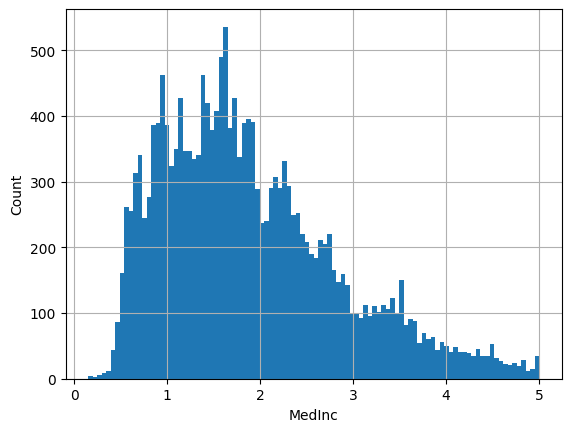

In [10]:
df_clean["MedHouseVal"].hist(bins=100)
plt.xlabel("MedInc")
plt.ylabel("Count")
plt.savefig("medinc_data.pdf", format="pdf")

In [ ]:
df_clean["MedHouseVal"].skew()

np.float64(0.834230327791469)

## Ergebnis

Da die Schiefe nur 0.834 beträgt, ist eine logarithmische Transformation des Targets nicht zwingend sinnvoll. Sie kann bei sehr schiefen Verteilungen hilfreich sein, ist hier aber nur begrenzt relevant.